# Windows


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# lets me import from a different directory
import sys 
sys.path.append("/Users/archie/documents/year4/project/code")

import spin_tools.hamiltonians as hamiltonians
from spin_tools.gates import *
import spin_tools.quantum_tools as qt
from spin_tools.floquet_tools import ccd_floquet


steel_blue, plum = "#4682B4", "#B44682"
deep_magenta = "#C12769"


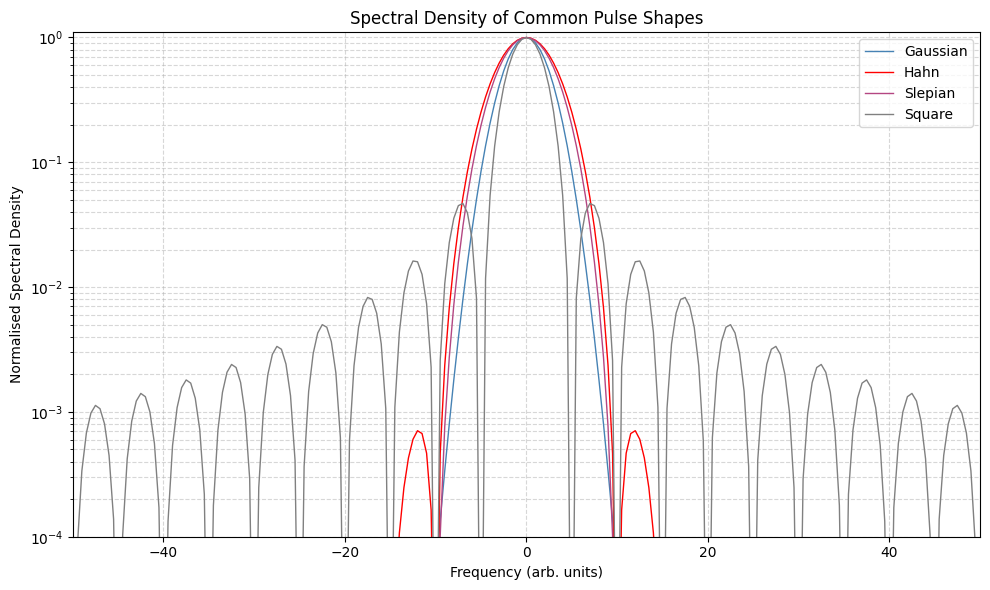

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft, fftshift
from scipy.signal.windows import dpss, hann

# Parameters
N = 2048
t = np.linspace(-1, 1, N, endpoint=False)
dt = t[1] - t[0]
fs = 1 / dt
freq = fftshift(np.fft.fftfreq(N, d=dt))

# Time window for pulses
pulse_width = 0.2
in_pulse = np.abs(t) < (pulse_width / 2)

# Define pulses
gaussian_pulse = np.exp(-t**2 / (2 * (pulse_width / 4)**2))

square_pulse = np.zeros_like(t)
square_pulse[in_pulse] = 1.0

hahn_pulse = np.zeros_like(t)
hahn_pulse[in_pulse] = hann(np.count_nonzero(in_pulse))

# Slepian (DPSS) pulse
NW = 1.8  # Time-bandwidth product
M = np.count_nonzero(in_pulse)
dpss_win = dpss(M, NW, Kmax=1)[0]
slepian_pulse = np.zeros_like(t)
slepian_pulse[in_pulse] = dpss_win

# Compute FFTs and normalise
def compute_spectrum(pulse):
    spectrum = fftshift(np.abs(fft(pulse))**2)
    spectrum /= np.max(spectrum)
    return spectrum

spectra = {
    'Gaussian': compute_spectrum(gaussian_pulse),
    'Hahn': compute_spectrum(hahn_pulse),
    'Slepian': compute_spectrum(slepian_pulse),
    'Square': compute_spectrum(square_pulse)
}

colours = {
    'Gaussian': steel_blue,
    'Hahn': '#FF0000',  # much redder
    'Slepian': plum,
    'Square': '#808080'  # grey
}

# Plot
plt.figure(figsize=(10, 6))
for label, spec in spectra.items():
    plt.plot(freq, spec, label=label, color=colours[label], lw=1)
plt.xlim(-50, 50)
plt.ylim(1e-4, 1.1)
plt.yscale('log')
plt.xlabel('Frequency (arb. units)')
plt.ylabel('Normalised Spectral Density')
plt.title('Spectral Density of Common Pulse Shapes')
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.tight_layout()

plt.show()